<a href="https://colab.research.google.com/github/SappidiLaxmiSriSai/Bank-Customer-Churn-Analytics/blob/main/Bank_Churn_Python_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importing our toolkits
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load the CSV file into a variable named 'df' (short for DataFrame)
df = pd.read_csv('Churn_Modelling.csv')

# View the first 5 rows of our data
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
# Get mean, min, max, and standard deviation for numerical columns
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
# Drop columns that have no analytical value
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Verify the remaining columns
df_clean.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
# Calculate total churn rate
churn_rate = df_clean['Exited'].mean() * 100
print(f"Overall Bank Churn Rate: {churn_rate:.2f}%")

Overall Bank Churn Rate: 20.37%


In [7]:
# Group by Geography and calculate churn rate
country_churn = df_clean.groupby('Geography')['Exited'].agg(['count', 'mean'])
country_churn['mean'] = country_churn['mean'] * 100
country_churn.columns = ['Total Customers', 'Churn Rate (%)']

print(country_churn)

           Total Customers  Churn Rate (%)
Geography                                 
France                5014       16.154767
Germany               2509       32.443204
Spain                 2477       16.673395


In [8]:
# Compare average age between loyal customers (0) and churned customers (1)
df_clean.groupby('Exited')['Age'].mean()

,Age
Exited,
0,37.408389
1,44.837997


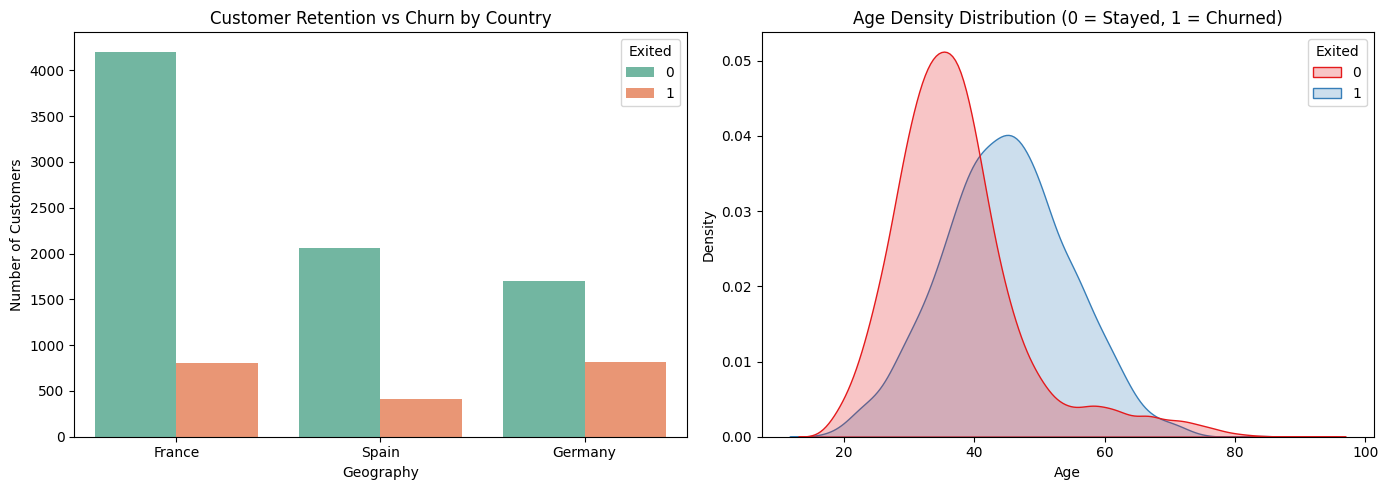

In [9]:
# Create a figure frame with 2 side-by-side chart slots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Churn Count by Geography
sns.countplot(x='Geography', hue='Exited', data=df_clean, ax=axes[0], palette='Set2')
axes[0].set_title('Customer Retention vs Churn by Country')
axes[0].set_ylabel('Number of Customers')

# Chart 2: Age Distribution for Stayed vs Exited
sns.kdeplot(data=df_clean, x='Age', hue='Exited', common_norm=False, ax=axes[1], fill=True, palette='Set1')
axes[1].set_title('Age Density Distribution (0 = Stayed, 1 = Churned)')

plt.tight_layout()
plt.show()

In [10]:
# Compare average balance for stayed (0) vs left (1)
print("--- Average Account Balance ---")
print(df_clean.groupby('Exited')['Balance'].mean())

print("\n--- Churn Rate by Active Member Status ---")
# 0 = Inactive Member, 1 = Active Member
active_churn = df_clean.groupby('IsActiveMember')['Exited'].mean() * 100
print(active_churn)

--- Average Account Balance ---
Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64

--- Churn Rate by Active Member Status ---
IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


In [11]:
import sqlite3

# Create an in-memory SQL database connection
conn = sqlite3.connect(':memory:')

# Upload our cleaned Python dataframe into an SQL table named 'bank_churn'
df_clean.to_sql('bank_churn', conn, index=False, if_exists='replace')

print("Database created! Your table 'bank_churn' is ready for SQL queries.")

Database created! Your table 'bank_churn' is ready for SQL queries.


In [12]:
query = """
SELECT *
FROM bank_churn
LIMIT 5;
"""
pd.read_sql_query(query, conn)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
query_1 = """
SELECT
    CASE
        WHEN Balance < 50000 THEN '1. Low Balance (<50k)'
        WHEN Balance BETWEEN 50000 AND 120000 THEN '2. Medium Balance (50k-120k)'
        ELSE '3. High Balance (>120k)'
    END AS balance_tier,
    COUNT(*) AS total_customers,
    SUM(Exited) AS churned_customers,
    ROUND(AVG(Exited) * 100, 2) AS churn_rate_pct
FROM bank_churn
GROUP BY balance_tier
ORDER BY balance_tier;
"""

# Execute the query and print results as a nice table
sql_result_1 = pd.read_sql_query(query_1, conn)
sql_result_1

,balance_tier,total_customers,churned_customers,churn_rate_pct
0,1. Low Balance (<50k),3692,526,14.25
1,2. Medium Balance (50k-120k),3127,746,23.86
2,3. High Balance (>120k),3181,765,24.05


In [14]:
query_2 = """
WITH ranked_churned_customers AS (
    SELECT
        Geography,
        Gender,
        Age,
        Balance,
        CreditScore,
        RANK() OVER (PARTITION BY Geography ORDER BY Balance DESC) as balance_rank
    FROM bank_churn
    WHERE Exited = 1
)
SELECT
    Geography,
    balance_rank,
    Age,
    Gender,
    CreditScore,
    ROUND(Balance, 2) AS Balance
FROM ranked_churned_customers
WHERE balance_rank <= 3;
"""

sql_result_2 = pd.read_sql_query(query_2, conn)
sql_result_2

,Geography,balance_rank,Age,Gender,CreditScore,Balance
0,France,1,57,Female,583,238387.56
1,France,2,35,Female,850,211774.31
2,France,3,21,Male,596,210433.08
3,Germany,1,41,Female,693,181461.48
4,Germany,2,40,Male,621,174126.75
5,Germany,3,47,Female,686,170935.94
6,Spain,1,38,Male,655,250898.09
7,Spain,2,42,Male,749,222267.63
8,Spain,3,58,Female,663,216109.88


In [15]:
# Save the cleaned dataframe as a CSV file to your local Colab environment
df_clean.to_csv('Bank_Churn_Cleaned.csv', index=False)

# Download it directly to your computer's Downloads folder
from google.colab import files
files.download('Bank_Churn_Cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>